In [1]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = fetch_california_housing()
X = data.data
y = data.target

In [9]:
tabular = pd.DataFrame(data.data, columns=data.feature_names)

print(tabular)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [17]:
model = keras.Sequential([
    keras.layers.Dense(256, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(1)
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
history = model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    verbose = 1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6588 - mae: 0.5400 - val_loss: 0.4018 - val_mae: 0.4442
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3758 - mae: 0.4352 - val_loss: 0.3712 - val_mae: 0.4240
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3551 - mae: 0.4185 - val_loss: 0.3549 - val_mae: 0.4148
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3302 - mae: 0.4045 - val_loss: 0.3545 - val_mae: 0.4072
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3156 - mae: 0.3926 - val_loss: 0.3460 - val_mae: 0.3987
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3243 - mae: 0.3885 - val_loss: 0.3311 - val_mae: 0.3868
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3052 - mae: 0.3825 - val_loss: 0.3247 - val_mae: 0.3934
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3011 - mae: 0.3800 - val_loss: 0.3279 - val_mae: 0.3979
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

model = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1)
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]

)

history = model.fit(
    X_train, y_train,
    validation_split = 0.2,
    epochs = 100,
    batch_size = 32,
    verbose = 1
)

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Model Evaluation:")
print(f"MSE  = {mse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Model Evaluation:
MSE  = 0.2728
MAE  = 0.3451
RMSE = 0.5223


In [20]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R² Score: 0.7918309755396411


In [27]:
from sklearn.metrics import r2_score

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, test_pred))

516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Train R²: 0.86944712454044
Test R² : 0.7918309755396411


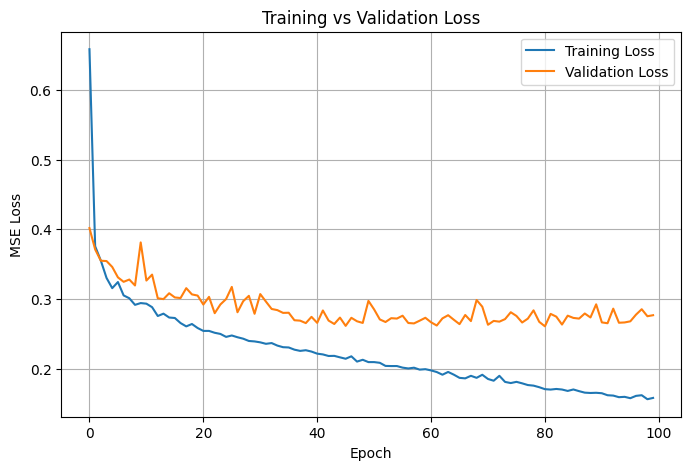

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

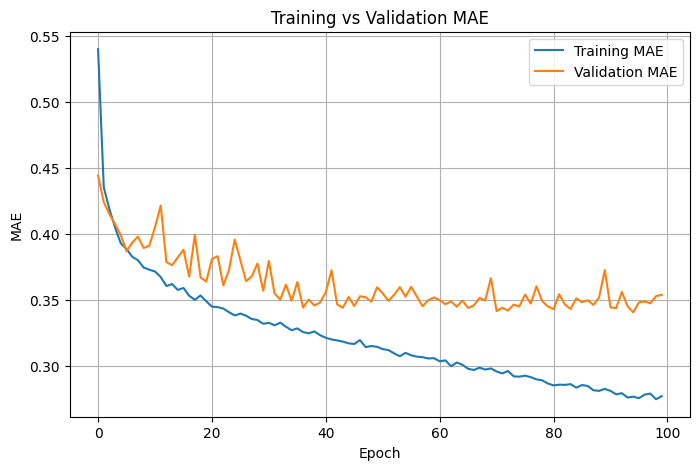

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training vs Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


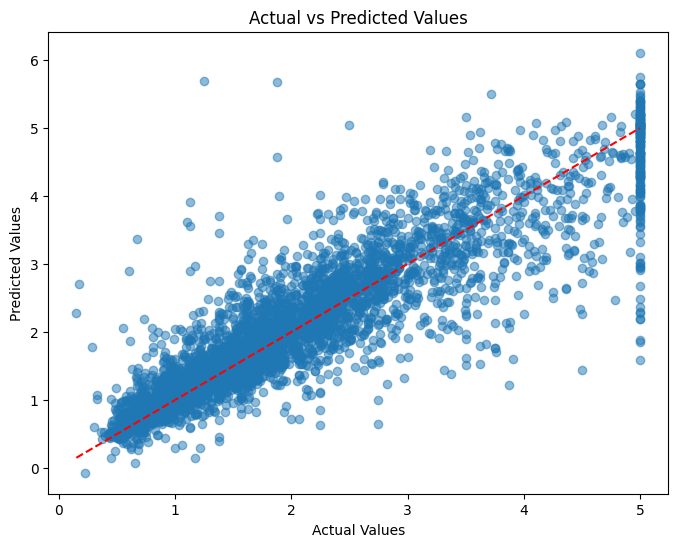

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

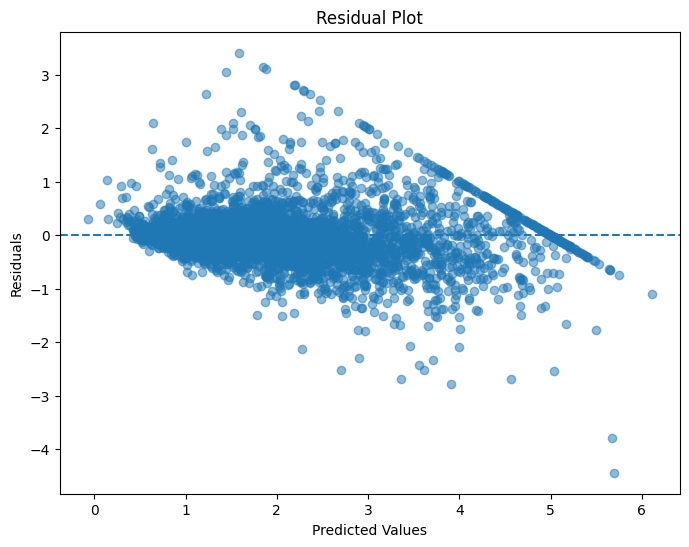

In [24]:
residuals = y_test - y_pred.flatten()

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [25]:
# Make predictions on the test set

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Actual Values:")
print(y_test[:10])

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
First 10 Predictions:
[[0.51176894]
 [0.6940652 ]
 [5.3640084 ]
 [2.4676528 ]
 [2.7974086 ]
 [1.5671438 ]
 [2.1755276 ]
 [1.6130865 ]
 [2.930507  ]
 [4.880344  ]]

First 10 Actual Values:
[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [26]:
import numpy as np

new_house = np.array([[
    8.3252,      # MedInc
    41.0,        # HouseAge
    6.984127,    # AveRooms
    1.023810,    # AveBedrms
    322.0,       # Population
    2.555556,    # AveOccup
    37.88,       # Latitude
    -122.23      # Longitude
]])

new_house_scaled = scalar.transform(new_house)

prediction = model.predict(new_house_scaled)

print(f"Predicted House Value: {prediction[0][0]:.4f}")
print(f"Approximate Price: ${prediction[0][0] * 100000:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted House Value: 4.2272
Approximate Price: $422,717.00
